# Inflation Forecasting with FRED-MD Data

Forecasts **1-month-ahead annualized PCE inflation (PCEPI)** using FRED-MD monthly vintages.

## Cell 1 — Setup, Imports & Helper Functions

In [3]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

# Resolve data paths (works from notebooks/ or repo root)
VINTAGE_DIR = '../data' if os.path.exists('../data') else 'data'

def setup_plot_style():
    """Set up matplotlib style for consistent plots."""
    sns.set_style("whitegrid")
    plt.rcParams['figure.figsize'] = (12, 6)
    plt.rcParams['font.size'] = 10

print("Vintage dir :", os.path.abspath(VINTAGE_DIR))
print("Vintage dir exists:", os.path.isdir(VINTAGE_DIR))

Vintage dir : /home/lukeholmes/2025-2026/ML/final-project/Macro-Econ-ML/notebooks/data
Vintage dir exists: True


In [4]:
# Helper functions (data loading + model)
import warnings
import datetime
import requests
from pathlib import Path
from dateutil.relativedelta import relativedelta
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# ---------------------------------------------------------------------------
# Transformation helpers
# ---------------------------------------------------------------------------

def _apply_tcode(series, code):
    """Apply a single FRED-MD transformation code to a pandas Series."""
    code = int(code)
    s = series.copy().astype(float)
    if code == 1:
        return s
    elif code == 2:
        return s.diff()
    elif code == 3:
        return s.diff().diff()
    elif code == 4:
        return np.log(s)
    elif code == 5:
        return np.log(s).diff() * 100
    elif code == 6:
        return np.log(s).diff().diff() * 100
    elif code == 7:
        pct = s / s.shift(1) - 1
        return pct.diff() * 100
    else:
        warnings.warn(f"Unknown tcode {code}, returning series unchanged.")
        return s


def apply_fred_md_transforms(df, tcodes):
    """
    Apply FRED-MD transformation codes to each column.

    Args:
        df: DataFrame with raw series (dates as index)
        tcodes: dict mapping column name -> tcode (int or float)

    Returns:
        Transformed DataFrame (same shape, NaNs introduced at boundaries)
    """
    transformed = {}
    for col in df.columns:
        if col in tcodes:
            transformed[col] = _apply_tcode(df[col], tcodes[col])
        else:
            transformed[col] = df[col].copy()
    return pd.DataFrame(transformed, index=df.index)


# ---------------------------------------------------------------------------
# Data loading functions
# ---------------------------------------------------------------------------

def load_fred_md_file(filepath):
    """
    Load a single FRED-MD CSV file.

    FRED-MD format:
      Row 1: transformation codes (tcode) for each series
      Row 2+: monthly observations

    Returns:
        Tuple (transformed_df, tcodes_dict)
    """
    filepath = str(filepath)
    raw_all = pd.read_csv(filepath, header=None)
    headers = raw_all.iloc[0].tolist()
    tcode_row = raw_all.iloc[1].tolist()

    date_col = headers[0]
    tcodes = {}
    for h, t in zip(headers[1:], tcode_row[1:]):
        try:
            tcodes[str(h)] = float(t)
        except (ValueError, TypeError):
            pass

    df = raw_all.iloc[2:].copy()
    df.columns = headers
    df = df.reset_index(drop=True)

    date_col_actual = df.columns[0]
    df[date_col_actual] = pd.to_datetime(df[date_col_actual])
    df = df.set_index(date_col_actual)
    df.index.name = 'date'
    df = df.dropna(how='all')

    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    df_transformed = apply_fred_md_transforms(df, tcodes)
    return df_transformed, tcodes


def get_latest_vintage(vintage_dir):
    """
    Find the most recent vintage CSV file in a directory.

    Vintage files are named like '2025-01.csv', '2024-12.csv', etc.

    Returns:
        Path to the most recent vintage file
    """
    vintage_dir = Path(vintage_dir)
    csv_files = list(vintage_dir.glob('*.csv'))
    if not csv_files:
        raise FileNotFoundError(f"No CSV files found in {vintage_dir}")
    csv_files_sorted = sorted(csv_files, key=lambda p: p.stem)
    latest = csv_files_sorted[-1]
    print(f"Using latest vintage: {latest.name}")
    return latest


def _is_valid_fred_md_csv(path):
    """Return True if the file looks like a real FRED-MD CSV (not an HTML error page)."""
    try:
        with open(path, 'r', errors='replace') as f:
            first_line = f.readline()
        lower = first_line.lower()
        return 'sasdate' in lower or (not lower.startswith('<') and ',' in first_line)
    except Exception:
        return False


def download_latest_vintage(data_dir):
    """Try current month then back up until a FRED-MD vintage CSV is found; download it.

    delta=0 (current month): always attempt download to ensure freshness and heal
    any corrupt/truncated cache. Falls back to cached copy on network failure or
    when the vintage hasn't been published yet.

    delta>=1 (older months): trust the cache — these are immutable snapshots and
    re-downloading is wasteful.
    """
    data_dir = Path(data_dir)
    data_dir.mkdir(parents=True, exist_ok=True)

    base_url = ("https://www.stlouisfed.org/-/media/project/frbstl/stlouisfed"
                "/research/fred-md/monthly/{year:04d}-{month:02d}-md.csv")

    today = datetime.date.today()
    for delta in range(6):   # try up to 6 months back
        candidate = today.replace(day=1) - relativedelta(months=delta)
        year, month = candidate.year, candidate.month
        filename = f"{year:04d}-{month:02d}-MD.csv"
        local_path = data_dir / filename

        # For older vintages (delta >= 1), trust the cache — they are immutable snapshots
        if delta >= 1 and local_path.exists():
            if _is_valid_fred_md_csv(local_path):
                print(f"Already have {filename}")
                return local_path
            else:
                print(f"Removing invalid cached file {filename}")
                local_path.unlink()

        # Always attempt download for delta=0 (current month) to ensure freshness
        url = base_url.format(year=year, month=month)
        try:
            resp = requests.get(url, timeout=30)
            if resp.status_code == 200:
                # Reject HTML responses (the Fed returns 200 for missing vintages)
                snippet = resp.content[:200].decode('utf-8', errors='replace')
                if '<html' in snippet.lower() or '<!doctype' in snippet.lower():
                    print(f"  {filename}: URL returned HTML — vintage not yet published")
                    # For delta=0: fall back to cached copy if it exists and is valid
                    if delta == 0 and local_path.exists() and _is_valid_fred_md_csv(local_path):
                        print(f"  Using cached {filename}")
                        return local_path
                    continue
                local_path.write_bytes(resp.content)
                print(f"Downloaded {filename}")
                print(local_path)
                return local_path
        except requests.RequestException:
            # Network failure: fall back to cached copy for delta=0
            if delta == 0 and local_path.exists() and _is_valid_fred_md_csv(local_path):
                print(f"  Network error — using cached {filename}")
                return local_path
    raise RuntimeError("Could not download any recent FRED-MD vintage.")


def build_dataset_from_csv(filepath, horizon=1, n_lags=2,
                            test_start='2025-06-01', val_start='2023-01-01'):
    """
    Build train/val/test datasets from a single FRED-MD vintage CSV.

    Target: PCEPI first-log-diff x100 (monthly % change), shifted by `horizon`.
    Features: all columns transformed by their tcodes, plus n_lags lagged copies
    of every feature (e.g. n_lags=3 adds _lag1, _lag2, _lag3 columns).
    Splits are date-based (no shuffling).
    """
    filepath = str(filepath)
    raw_all = pd.read_csv(filepath, header=None)
    headers = raw_all.iloc[0].tolist()
    tcode_row = raw_all.iloc[1].tolist()

    # Build tcode dict
    tcodes = {}
    for h, t in zip(headers[1:], tcode_row[1:]):
        try:
            tcodes[str(h)] = float(t)
        except (ValueError, TypeError):
            pass

    # Raw data (before tcode transforms)
    df_raw = raw_all.iloc[2:].copy()
    df_raw.columns = headers
    df_raw = df_raw.reset_index(drop=True)
    date_col = df_raw.columns[0]
    df_raw[date_col] = pd.to_datetime(df_raw[date_col])
    df_raw = df_raw.set_index(date_col)
    df_raw.index.name = 'date'
    df_raw = df_raw.dropna(how='all')
    for col in df_raw.columns:
        df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')

    # --- Build target from raw PCEPI levels ---
    pcepi_raw = df_raw['PCEPI']
    target = np.log(pcepi_raw).diff() * 100   # first log diff x100
    target_shifted = target.shift(-horizon)    # y[t] = inflation at t+horizon

    # --- Build features (tcode-transformed) ---
    df_features = apply_fred_md_transforms(df_raw, tcodes)
    df_features = df_features.ffill().bfill()
    # --- Add lagged features ---
    if n_lags > 0:
        base_cols = df_features.columns.tolist()
        lag_frames = [df_features]
        for lag in range(1, n_lags + 1):
            lag_df = df_features[base_cols].shift(lag)
            lag_df.columns = [f"{c}_lag{lag}" for c in base_cols]
            lag_frames.append(lag_df)
        df_features = pd.concat(lag_frames, axis=1)

    # Combine and drop rows with any NaN (target or lagged features)
    df = df_features.copy()
    df['_target'] = target_shifted
    df = df.dropna()

    X = df.drop(columns=['_target'])
    y = df['_target']

    # Drop all-NaN feature columns
    X = X.dropna(axis=1, how='all')
    feature_names = X.columns.tolist()

    # Date-based splits
    test_mask  = X.index >= pd.Timestamp(test_start)
    val_mask   = (X.index >= pd.Timestamp(val_start)) & ~test_mask
    train_mask = ~val_mask & ~test_mask

    X_train, y_train = X[train_mask], y[train_mask]
    X_val,   y_val   = X[val_mask],   y[val_mask]
    X_test,  y_test  = X[test_mask],  y[test_mask]

    print(f"\nDataset summary (PCEPI first-log-diff target, {horizon}-month-ahead):")
    print(f"  Train : {len(X_train):4d} obs  {X_train.index.min().date()} -> {X_train.index.max().date()}")
    print(f"  Val   : {len(X_val):4d} obs  {X_val.index.min().date()} -> {X_val.index.max().date()}")
    print(f"  Test  : {len(X_test):4d} obs  {X_test.index.min().date()} -> {X_test.index.max().date()}")
    base_count = len([f for f in feature_names if '_lag' not in f])
    print(f"  Features: {len(feature_names)} ({base_count} base × {n_lags + 1} time steps)")

    return X_train, y_train, X_val, y_val, X_test, y_test, feature_names


# ---------------------------------------------------------------------------
# Model
# ---------------------------------------------------------------------------

class InflationForecaster:
    """ElasticNet forecaster for inflation time series."""

    def __init__(self, random_state=42):
        self.random_state = random_state
        self.model = None
        self.scaler = StandardScaler()
        self.best_params = None

    def _get_model(self):
        return ElasticNet(random_state=self.random_state, max_iter=100000)

    def _get_param_grid(self):
        return {
            'alpha': [0.00001, 0.0001, 0.001, 0.01, 0.1, 1.0],  # Add tiny alphas
            'l1_ratio': [0.3, 0.5, 0.7],  # Don't need all the way to 0.9
        }


    def train(self, X_train, y_train, tune_hyperparameters=True, cv_folds=5):
        X_train_scaled = self.scaler.fit_transform(X_train)
        if tune_hyperparameters:
            print("Tuning ElasticNet hyperparameters...")
            tscv = TimeSeriesSplit(n_splits=cv_folds)
            grid_search = GridSearchCV(
                self._get_model(),
                self._get_param_grid(),
                cv=tscv,
                scoring='neg_mean_squared_error',
                n_jobs=-1,
                verbose=1,
            )
            grid_search.fit(X_train_scaled, y_train)
            self.model = grid_search.best_estimator_
            self.best_params = grid_search.best_params_
            print(f"Best parameters: {self.best_params}")
            print(f"Best CV score (RMSE): {np.sqrt(-grid_search.best_score_):.4f}")
        else:
            print("Training ElasticNet with default parameters...")
            self.model = self._get_model()
            self.model.fit(X_train_scaled, y_train)
        return self

    def predict(self, X):
        if self.model is None:
            raise ValueError("Model must be trained before making predictions")
        return self.model.predict(self.scaler.transform(X))

    def evaluate(self, X_test, y_test):
        y_pred = self.predict(X_test)
        metrics = {
            'rmse': np.sqrt(mean_squared_error(y_test, y_pred)),
            'mae': mean_absolute_error(y_test, y_pred),
            'r2': r2_score(y_test, y_pred),
            'mape': np.mean(np.abs((y_test - y_pred) / (y_test + 1e-10))) * 100,
        }
        return metrics, y_pred

    def get_feature_importance(self, feature_names):
        if self.model is None:
            raise ValueError("Model must be trained first")
        if hasattr(self.model, 'coef_'):
            importance = np.abs(self.model.coef_)
        elif hasattr(self.model, 'feature_importances_'):
            importance = self.model.feature_importances_
        else:
            return None
        return pd.DataFrame({
            'feature': feature_names,
            'importance': importance,
        }).sort_values('importance', ascending=False)

## Cell 2 — Data Loading

In [5]:
# Download (or locate) most recent FRED-MD vintage
vintage_file = download_latest_vintage(VINTAGE_DIR)

N_LAGS = 2          # lagged months added as features (0 = single-snapshot)
ROLLING_WINDOW = 48  # months of training history used for fitting (0 = all history)
                     # 24-month window follows Cleveland Fed short rolling-window insight

# Build dataset entirely from CSV
X_train, y_train, X_val, y_val, X_test, y_test, feature_names = build_dataset_from_csv(
    filepath=vintage_file,
    horizon=1,
    n_lags=N_LAGS,
    test_start='2025-06-01',
    val_start='2023-01-01',
)

print(f"\nTrain  samples : {len(X_train)}  features: {len(feature_names)}")
print(f"  Date range   : {X_train.index.min().date()} -> {X_train.index.max().date()}")
print(f"\nVal    samples : {len(X_val)}")
print(f"  Date range   : {X_val.index.min().date()} -> {X_val.index.max().date()}")
print(f"\nTest   samples : {len(X_test)}")
if len(X_test):
    print(f"  Date range   : {X_test.index.min().date()} -> {X_test.index.max().date()}")

  2026-04-MD.csv: URL returned HTML — vintage not yet published
  2026-03-MD.csv: URL returned HTML — vintage not yet published
Already have 2026-02-MD.csv

Dataset summary (PCEPI first-log-diff target, 1-month-ahead):
  Train :  766 obs  1959-03-01 -> 2022-12-01
  Val   :   29 obs  2023-01-01 -> 2025-05-01
  Test  :    6 obs  2025-06-01 -> 2025-11-01
  Features: 378 (126 base × 3 time steps)

Train  samples : 766  features: 378
  Date range   : 1959-03-01 -> 2022-12-01

Val    samples : 29
  Date range   : 2023-01-01 -> 2025-05-01

Test   samples : 6
  Date range   : 2025-06-01 -> 2025-11-01


In [6]:
# Load raw (transformed) vintage file to inspect PCEPI growth series
df_train_full, tcodes = load_fred_md_file(vintage_file)

# Show tcodes for key series
key_series = ['PCEPI', 'CPIAUCSL', 'UNRATE', 'FEDFUNDS', 'TB3MS', 'GS10', 'INDPRO', 'HOUST']
tcode_info = {s: tcodes.get(s, 'N/A') for s in key_series if s in tcodes or s in df_train_full.columns}
tcode_df = pd.DataFrame(list(tcode_info.items()), columns=['Series', 'TCode'])
tcode_descriptions = {
    1: 'No transform', 2: '1st diff', 3: '2nd diff',
    4: 'Log', 5: 'Log 1st diff x100', 6: 'Log 1st diff x100', 7: 'Delta pct chg x100'
}
tcode_df['Transform'] = tcode_df['TCode'].map(lambda x: tcode_descriptions.get(int(x), str(x)) if x != 'N/A' else 'N/A')
print("Transformation codes for key series:")
print(tcode_df.to_string(index=False))


print("\nLag structure: y[t] = PCEPI growth at t+1 (1-month-ahead forecast)")
print(f"  Features cover: {X_train.index.min().date()} to {X_train.index.max().date()}")
print(f"  y[t] covers   : {y_train.index.min().date()} to {y_train.index.max().date()}")

Transformation codes for key series:
  Series  TCode         Transform
   PCEPI    6.0 Log 1st diff x100
CPIAUCSL    6.0 Log 1st diff x100
  UNRATE    2.0          1st diff
FEDFUNDS    2.0          1st diff
   TB3MS    2.0          1st diff
    GS10    2.0          1st diff
  INDPRO    5.0 Log 1st diff x100
   HOUST    4.0               Log

Lag structure: y[t] = PCEPI growth at t+1 (1-month-ahead forecast)
  Features cover: 1959-03-01 to 2022-12-01
  y[t] covers   : 1959-03-01 to 2022-12-01


## Cell 4 — Exploratory Data Analysis

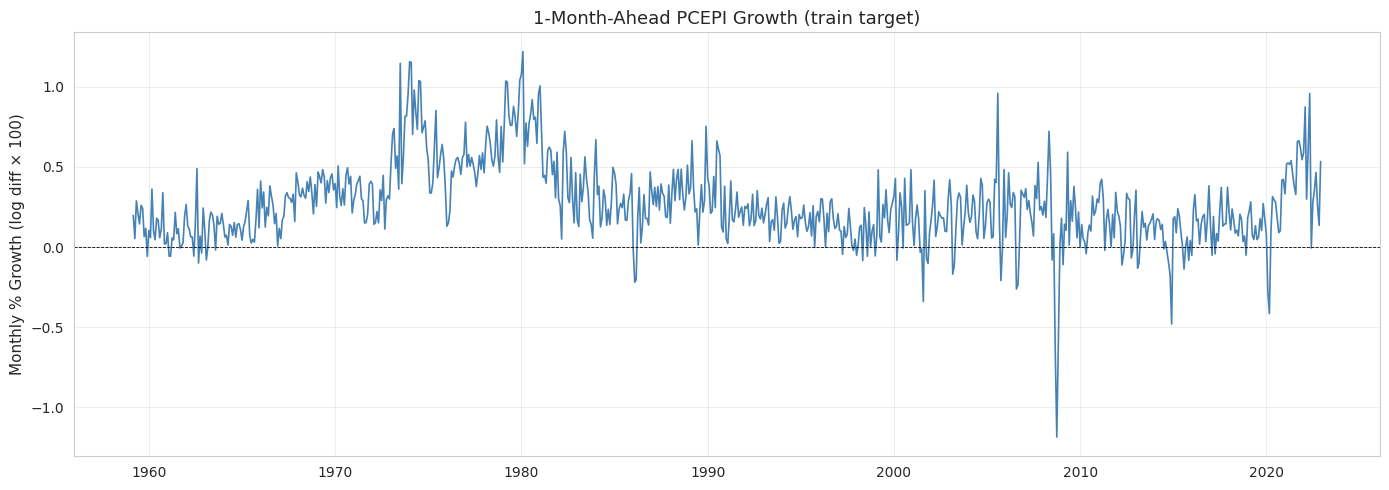

Top 15 features correlated with 1-month-ahead PCEPI growth:
TB3SMFFM         0.471
TB3SMFFM_lag1    0.459
TB3SMFFM_lag2    0.448
TB6SMFFM         0.444
TB6SMFFM_lag1    0.434
AAAFFM           0.431
AAAFFM_lag1      0.424
ACOGNO           0.419
TB6SMFFM_lag2    0.418
AAAFFM_lag2      0.412
COMPAPFFx        0.397
T10YFFM_lag1     0.397
T10YFFM          0.396
BUSINVx          0.392
T10YFFM_lag2     0.389


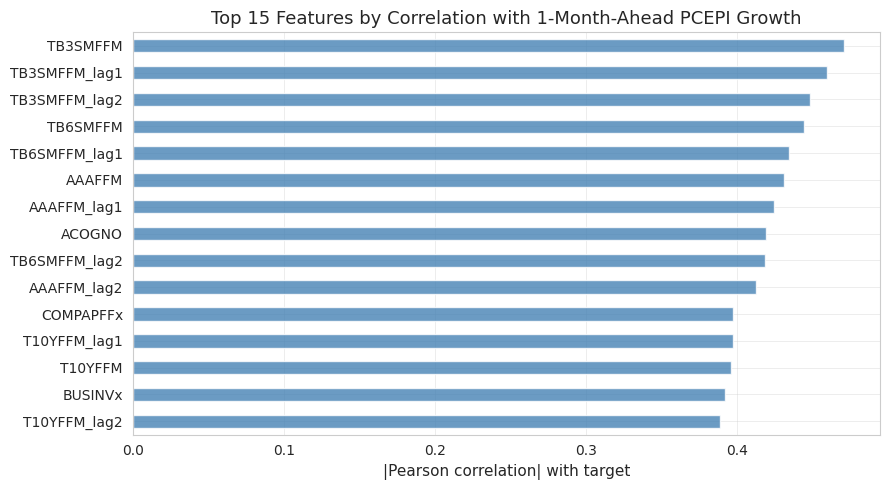

In [7]:
fig, ax = plt.subplots(figsize=(14, 5))

# --- PCEPI 1-month-ahead target over time ---
ax.plot(y_train.index, y_train.values, linewidth=1.2, color='steelblue')
ax.axhline(0, color='black', linewidth=0.6, linestyle='--')
ax.set_title('1-Month-Ahead PCEPI Growth (train target)')
ax.set_ylabel('Monthly % Growth (log diff × 100)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.tight_layout()
plt.show()

# --- Top 15 features correlated with target ---
corr = X_train.corrwith(y_train).abs().dropna().sort_values(ascending=False)
print("Top 15 features correlated with 1-month-ahead PCEPI growth:")
print(corr.head(15).round(3).to_string())

top_corr = corr.head(15)
if len(top_corr) > 0:
    fig2, ax2 = plt.subplots(figsize=(9, 5))
    top_corr.plot(kind='barh', ax=ax2, color='steelblue', alpha=0.8)
    ax2.set_xlabel('|Pearson correlation| with target')
    ax2.set_title('Top 15 Features by Correlation with 1-Month-Ahead PCEPI Growth')
    ax2.invert_yaxis()
    fig2.tight_layout()
    plt.show()
else:
    print("No valid correlations computed (all NaN).")

## Cell 5 — Train ElasticNet

Rolling window: fitting on last 48 months (2019-01-01 → 2022-12-01), CV folds: 9
Tuning ElasticNet hyperparameters...
Fitting 9 folds for each of 18 candidates, totalling 162 fits
Best parameters: {'alpha': 0.1, 'l1_ratio': 0.3}
Best CV score (RMSE): 0.2621
TimeSeriesSplit CV results (ElasticNet, best params):
 fold  n_val     rmse      mae         r2
    1      4 0.320182 0.257783  -1.010060
    2      4 0.465066 0.324881 -76.771951
    3      4 0.263848 0.222427  -1.634960
    4      4 0.332910 0.314806 -15.665160
    5      4 0.146995 0.141013  -2.416754
    6      4 0.256929 0.252105 -28.346106
    7      4 0.264156 0.222435  -0.672370
    8      4 0.377119 0.305969  -0.151630
    9      4 0.204524 0.159577  -0.643211

Mean CV RMSE: 0.2924  |  Mean R²: -14.1458
Best hyperparams: {'alpha': 0.1, 'l1_ratio': 0.3}


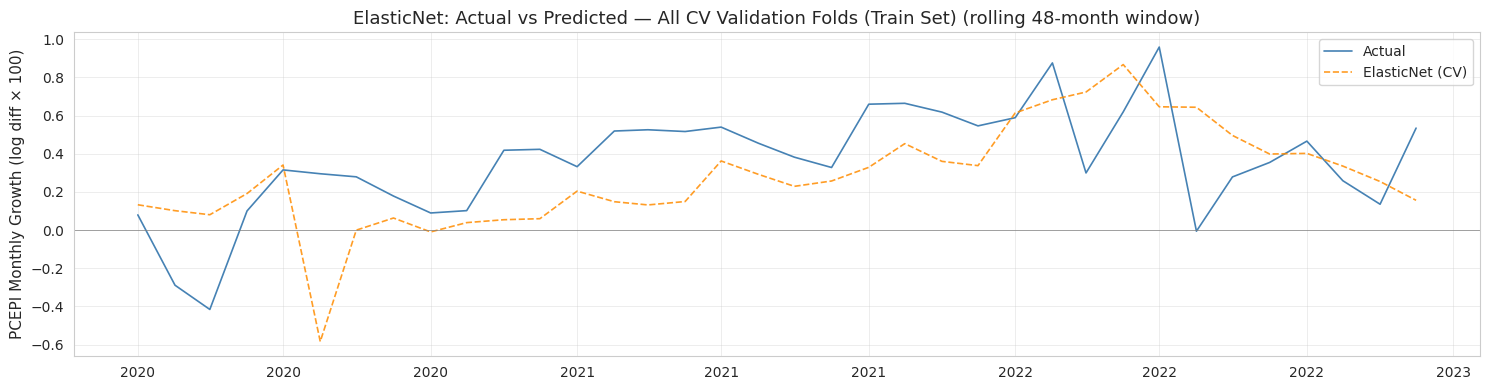

In [8]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

CV_FOLDS = 10   # single place to adjust

# Rolling window: restrict training data to most recent ROLLING_WINDOW months.
# Short windows let the model adapt to recent inflation regimes (Cleveland Fed insight).
if ROLLING_WINDOW > 0:
    X_train_fit = X_train.iloc[-ROLLING_WINDOW:]
    y_train_fit = y_train.iloc[-ROLLING_WINDOW:]
    cv_folds_fit = min(CV_FOLDS, max(2, ROLLING_WINDOW // 5))
    print(f"Rolling window: fitting on last {ROLLING_WINDOW} months "
          f"({X_train_fit.index.min().date()} → {X_train_fit.index.max().date()}), "
          f"CV folds: {cv_folds_fit}")
else:
    X_train_fit = X_train
    y_train_fit = y_train
    cv_folds_fit = CV_FOLDS

# --- Train ElasticNet with TimeSeriesSplit CV ---
elasticnet = InflationForecaster(random_state=42)
elasticnet.train(X_train_fit, y_train_fit, tune_hyperparameters=True, cv_folds=cv_folds_fit)

# --- Cross-validation fold performance ---
tscv = TimeSeriesSplit(n_splits=cv_folds_fit)
fold_metrics = []
all_val_dates = []
all_val_actual = []
all_val_pred = []

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet

best_alpha    = elasticnet.best_params.get('alpha', 0.1)
best_l1_ratio = elasticnet.best_params.get('l1_ratio', 0.5)
X_arr = X_train_fit.values
y_arr = y_train_fit.values

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_arr)):
    scaler = StandardScaler()
    Xtr  = scaler.fit_transform(X_arr[tr_idx])
    Xval = scaler.transform(X_arr[val_idx])
    ytr, yval = y_arr[tr_idx], y_arr[val_idx]

    m = ElasticNet(alpha=best_alpha, l1_ratio=best_l1_ratio, max_iter=100000, random_state=42)
    m.fit(Xtr, ytr)
    pred = m.predict(Xval)

    fold_metrics.append({
        'fold':  fold + 1,
        'n_val': len(yval),
        'rmse':  np.sqrt(mean_squared_error(yval, pred)),
        'mae':   mean_absolute_error(yval, pred),
        'r2':    r2_score(yval, pred),
    })

    all_val_dates.extend(X_train_fit.index[val_idx])
    all_val_actual.extend(yval)
    all_val_pred.extend(pred)

cv_df = pd.DataFrame(fold_metrics)
print('TimeSeriesSplit CV results (ElasticNet, best params):')
print(cv_df.to_string(index=False))
print(f'\nMean CV RMSE: {cv_df["rmse"].mean():.4f}  |  Mean R²: {cv_df["r2"].mean():.4f}')
print(f'Best hyperparams: {elasticnet.best_params}')

# --- Plot predictions across all CV folds ---
all_val_dates  = pd.DatetimeIndex(all_val_dates)
all_val_actual = np.array(all_val_actual)
all_val_pred   = np.array(all_val_pred)

fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(all_val_dates, all_val_actual, '-',  label='Actual',          linewidth=1.2, color='steelblue')
ax.plot(all_val_dates, all_val_pred,   '--', label='ElasticNet (CV)', linewidth=1.2, alpha=0.85, color='darkorange')
ax.axhline(0, color='grey', linewidth=0.5)
title_suffix = f' (rolling {ROLLING_WINDOW}-month window)' if ROLLING_WINDOW > 0 else ''
ax.set_title(f'ElasticNet: Actual vs Predicted — All CV Validation Folds (Train Set){title_suffix}')
ax.set_ylabel('PCEPI Monthly Growth (log diff × 100)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.tight_layout()
plt.show()


Out-of-Sample Test Performance (ElasticNet, held-out 15%):
  Test date range: 2025-06-01 to 2025-11-01
  n observations : 6
  RMSE : 0.0950
  MAE  : 0.0792
  R²   : -1.5278
  MAPE : 35.01%
Vintage anchor (latest data)  : 2026-01-01
Chain start (last test obs)   : 2025-11-01
Current month                 : 2026-04-01
Total forecast steps          : 5

  LATEST FORECASTS
  Vintage anchor: 2026-01-01  |  Chain start: 2025-11-01
  Dec 2025 (step  1) (data-anchored): +0.2993% monthly  (+2.80% YoY)
  Jan 2026 (step  2) (data-anchored): +0.2307% monthly  (+2.74% YoY)
  Feb 2026 (step  3) (chained)     : +0.3367% monthly  (+2.68% YoY)
  Mar 2026 (step  4) (chained)     : +0.2859% monthly  (+2.95% YoY)
  Apr 2026 (step  5) (chained)     : +0.2885% monthly  (+3.07% YoY)


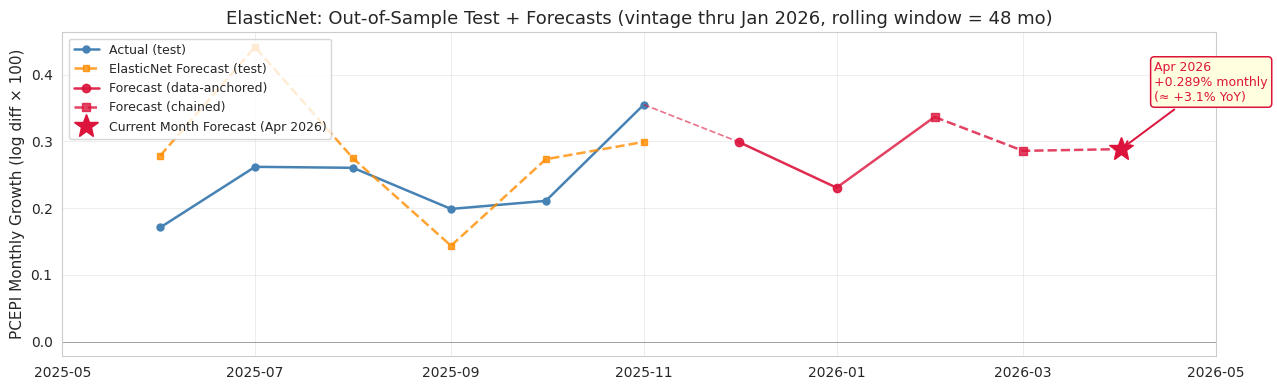

In [9]:
y_test_pred = np.array([])
if len(X_test) == 0:
    print('WARNING: No out-of-sample test observations available.')
else:
    # Align test features to training feature set
    test_cols = [c for c in feature_names if c in X_test.columns]
    X_test_aligned = X_test[test_cols]

    test_metrics, y_test_pred = elasticnet.evaluate(X_test_aligned, y_test)

    print(f'Out-of-Sample Test Performance (ElasticNet, held-out 15%):')
    print(f'  Test date range: {X_test.index.min().date()} to {X_test.index.max().date()}')
    print(f'  n observations : {len(X_test)}')
    print(f'  RMSE : {test_metrics["rmse"]:.4f}')
    print(f'  MAE  : {test_metrics["mae"]:.4f}')
    print(f'  R²   : {test_metrics["r2"]:.4f}')
    print(f'  MAPE : {test_metrics["mape"]:.2f}%')

# ---------------------------------------------------------------------------
# Build raw data and feature matrix from vintage CSV
# ---------------------------------------------------------------------------
import warnings

raw_all = pd.read_csv(str(vintage_file), header=None)
headers_raw   = raw_all.iloc[0].tolist()
tcode_row_raw = raw_all.iloc[1].tolist()
tcodes_raw = {}
for h, t in zip(headers_raw[1:], tcode_row_raw[1:]):
    try:
        tcodes_raw[str(h)] = float(t)
    except (ValueError, TypeError):
        pass
df_raw2 = raw_all.iloc[2:].copy()
df_raw2.columns = headers_raw
df_raw2 = df_raw2.reset_index(drop=True)
dc = df_raw2.columns[0]
df_raw2[dc] = pd.to_datetime(df_raw2[dc])
df_raw2 = df_raw2.set_index(dc)
df_raw2.index.name = 'date'
df_raw2 = df_raw2.dropna(how='all')
for col in df_raw2.columns:
    df_raw2[col] = pd.to_numeric(df_raw2[col], errors='coerce')

# Transformed feature matrix with forward-fill for partial months (ragged edge)
df_feat2 = apply_fred_md_transforms(df_raw2, tcodes_raw).ffill().bfill()

# ---------------------------------------------------------------------------
# Chain parameters
# ---------------------------------------------------------------------------
TARGET_FEATURE = 'PCEPI'
anchor_date   = df_feat2.index.max()    # latest month with data in vintage
current_month = pd.Timestamp(datetime.date.today().replace(day=1))

# Start the chain from the last observed test date so the red forecast line
# covers every month between the last known observation and today.
if len(X_test) > 0:
    chain_start_date = X_test.index.max()
else:
    chain_start_date = anchor_date - pd.DateOffset(months=1)

total_forecast_steps = (
    (current_month.year  - chain_start_date.year)  * 12 +
    (current_month.month - chain_start_date.month)
)

print(f'Vintage anchor (latest data)  : {anchor_date.date()}')
print(f'Chain start (last test obs)   : {chain_start_date.date()}')
print(f'Current month                 : {current_month.date()}')
print(f'Total forecast steps          : {total_forecast_steps}')

# ---------------------------------------------------------------------------
# Build rolling history buffer initialised at chain_start_date
#
# For months between chain_start_date and anchor_date the vintage already
# contains real (if partial) feature data.  We use it to anchor the buffer
# so that, e.g., the Feb forecast uses actual Jan values wherever available,
# with ffill covering only the NaN entries.  Only months AFTER anchor_date
# are purely chained (PCEPI updated from prediction, others held constant).
# ---------------------------------------------------------------------------
import re as _re

train_medians      = X_train_fit.median().reindex(feature_names)
base_feature_names = [f for f in feature_names if not _re.search(r'_lag\d+$', f)]
train_medians_base = X_train_fit[base_feature_names].median()

buffer = {}
for k in range(N_LAGS + 1):
    lag_date  = chain_start_date - pd.DateOffset(months=k)
    available = df_feat2.index[df_feat2.index <= lag_date]
    if len(available) > 0:
        row = df_feat2.loc[available[-1], base_feature_names]
    else:
        row = train_medians_base
    buffer[k] = row.fillna(train_medians_base)

def _assemble_row(buf, base_cols, all_cols, n_lags, fallback):
    d = {}
    for col in base_cols:
        if col in all_cols:
            d[col] = buf[0].get(col, fallback.get(col, float('nan')))
    for k in range(1, n_lags + 1):
        for col in base_cols:
            lc = f'{col}_lag{k}'
            if lc in all_cols:
                d[lc] = buf[k].get(col, fallback.get(col, float('nan'))) if k in buf else fallback.get(col, float('nan'))
    return pd.DataFrame([d]).reindex(columns=all_cols).fillna(fallback)

pcepi_growth = np.log(df_raw2[TARGET_FEATURE]).diff() * 100

# Initialise prev_growth at chain_start_date
if chain_start_date in pcepi_growth.index and pd.notna(pcepi_growth.loc[chain_start_date]):
    prev_growth = float(pcepi_growth.loc[chain_start_date])
else:
    avail_g = pcepi_growth.loc[:chain_start_date].dropna()
    prev_growth = float(avail_g.iloc[-1]) if len(avail_g) > 0 else 0.0

# ---------------------------------------------------------------------------
# Forecast loop
# ---------------------------------------------------------------------------
forecast_rows = []

for step in range(1, total_forecast_steps + 1):
    X_current = _assemble_row(buffer, base_feature_names, feature_names, N_LAGS, train_medians)

    nan_cols = X_current.columns[X_current.isna().any()].tolist()
    if nan_cols:
        raise ValueError(f'NaNs remain in forecast features at step {step}: {nan_cols[:10]}')

    pred          = float(elasticnet.predict(X_current)[0])
    forecast_date = chain_start_date + pd.DateOffset(months=step)
    is_anchored   = forecast_date in df_feat2.index  # True → real vintage data available

    # YoY calculation: rolling sum of 12 consecutive monthly log-diffs ending
    # at forecast_date.  Priority: (1) actual pcepi_growth, (2) earlier predicted
    # steps, (3) current step prediction.
    prior_preds = {r['date']: r['forecast'] for r in forecast_rows}
    monthly_growths = []
    for i in range(12):
        month = forecast_date - pd.DateOffset(months=11 - i)
        if month == forecast_date:
            monthly_growths.append(pred)
        elif month in pcepi_growth.index and pd.notna(pcepi_growth.loc[month]):
            monthly_growths.append(float(pcepi_growth.loc[month]))
        elif month in prior_preds:
            monthly_growths.append(prior_preds[month])
        else:
            monthly_growths = None
            break
    yoy = sum(monthly_growths) if monthly_growths is not None else float('nan')

    forecast_rows.append({
        'step':             step,
        'date':             forecast_date,
        'forecast':         pred,        # monthly log-diff × 100
        'annualized_naive': pred * 12,   # naive × 12 (for reference)
        'yoy_equivalent':   yoy,         # correct rolling 12-month sum
        'anchored':         is_anchored,
    })

    # Buffer update: use actual vintage data where it exists (≤ anchor_date),
    # otherwise advance PCEPI from prediction and hold all other features fixed.
    if is_anchored:
        new_base_row = df_feat2.loc[forecast_date, base_feature_names].fillna(train_medians_base)
        if forecast_date in pcepi_growth.index and pd.notna(pcepi_growth.loc[forecast_date]):
            prev_growth = float(pcepi_growth.loc[forecast_date])
        else:
            prev_growth = pred
    else:
        new_base_row = buffer[0].copy()
        if TARGET_FEATURE in new_base_row.index:
            new_base_row[TARGET_FEATURE] = pred - prev_growth
        prev_growth = pred

    for k in range(N_LAGS, 0, -1):
        buffer[k] = buffer[k - 1]
    buffer[0] = new_base_row.fillna(train_medians_base)

forecast_df = pd.DataFrame(forecast_rows)

# ---------------------------------------------------------------------------
# Print results
# ---------------------------------------------------------------------------
print(f"\n{'='*70}")
print('  LATEST FORECASTS')
print(f'  Vintage anchor: {anchor_date.date()}  |  Chain start: {chain_start_date.date()}')
for row in forecast_rows:
    month_label = row['date'].strftime('%b %Y')
    tag = '(data-anchored)' if row['anchored'] else '(chained)     '
    yoy_str = f"{row['yoy_equivalent']:+.2f}% YoY" if not np.isnan(row['yoy_equivalent']) else 'YoY: N/A'
    print(f"  {month_label} (step {row['step']:2d}) {tag}: "
          f"{row['forecast']:+.4f}% monthly  ({yoy_str})")
print(f"{'='*70}")

# ---------------------------------------------------------------------------
# Plot: test actuals + forecasts
# Solid circles = data-anchored (real vintage features used for that step)
# Dashed squares = purely chained (post-anchor extrapolation)
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(13, 4))

if len(X_test) > 0:
    ax.plot(y_test.index, y_test.values, 'o-', label='Actual (test)', linewidth=1.8,
            markersize=5, color='steelblue')
    ax.plot(y_test.index, y_test_pred, 's--', label='ElasticNet Forecast (test)',
            linewidth=1.8, alpha=0.8, markersize=5, color='darkorange')

    # Connector from last test obs to first forecast step
    last_test_date = y_test.index[-1]
    last_test_val  = y_test.values[-1]
    first_forecast = forecast_df.iloc[0]
    ax.plot([last_test_date, first_forecast['date']],
            [last_test_val,  first_forecast['forecast']],
            '--', color='crimson', linewidth=1.2, alpha=0.6)

anchored_df = forecast_df[forecast_df['anchored']]
chained_df  = forecast_df[~forecast_df['anchored']]

if not anchored_df.empty:
    ax.plot(anchored_df['date'], anchored_df['forecast'],
            'o-', color='crimson', linewidth=1.8, alpha=0.9, markersize=6,
            label='Forecast (data-anchored)')

if not chained_df.empty:
    ax.plot(chained_df['date'], chained_df['forecast'],
            's--', color='crimson', linewidth=1.8, alpha=0.8, markersize=6,
            label='Forecast (chained)')

# Connect anchored to chained segments seamlessly
if not anchored_df.empty and not chained_df.empty:
    last_a  = anchored_df.iloc[-1]
    first_c = chained_df.iloc[0]
    ax.plot([last_a['date'], first_c['date']], [last_a['forecast'], first_c['forecast']],
            '-', color='crimson', linewidth=1.8, alpha=0.8)

# Star on current-month forecast (last step)
last_row = forecast_df.iloc[-1]
ax.plot(last_row['date'], last_row['forecast'],
        '*', color='crimson', markersize=18, zorder=5,
        label=f"Current Month Forecast ({last_row['date'].strftime('%b %Y')})")

ax.annotate(
    f"{last_row['date'].strftime('%b %Y')}\n{last_row['forecast']:+.3f}% monthly\n"
    f"(≈ {last_row['yoy_equivalent']:+.1f}% YoY)" if not np.isnan(last_row['yoy_equivalent'])
    else f"{last_row['date'].strftime('%b %Y')}\n{last_row['forecast']:+.3f}% monthly",
    xy=(last_row['date'], last_row['forecast']),
    xytext=(24, 35), textcoords='offset points',
    fontsize=9, color='crimson',
    arrowprops=dict(arrowstyle='->', color='crimson', lw=1.4),
    bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', ec='crimson', lw=1.1),
)

ax.axhline(0, color='grey', linewidth=0.5)
ax.set_title(
    f'ElasticNet: Out-of-Sample Test + Forecasts'
    f' (vintage thru {anchor_date.strftime("%b %Y")}, rolling window = {ROLLING_WINDOW} mo)'
)
ax.set_ylabel('PCEPI Monthly Growth (log diff × 100)')
ax.legend(loc='upper left', fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
left_bound = (y_test.index.min() - pd.DateOffset(months=1)
              if len(X_test) > 0 else anchor_date - pd.DateOffset(months=12))
right_bound = forecast_df['date'].max() + pd.DateOffset(months=1)
ax.set_xlim(left=left_bound, right=right_bound)
fig.tight_layout()
plt.show()


## Cell 8 — Feature Importance

Top 15 features by |ElasticNet coefficient|:
             feature  importance
             CLAIMSx    0.055141
             T10YFFM    0.053103
        AMDMUOx_lag2    0.044036
        BUSINVx_lag2    0.035670
            PERMITMW    0.025294
         PPICMM_lag1    0.024809
         REALLN_lag1    0.012591
      UEMP15T26_lag2    0.010739
DNDGRG3M086SBEA_lag2    0.009644
       CPIMEDSL_lag1    0.008544
DNDGRG3M086SBEA_lag1    0.007711
       CUSR0000SA0L5    0.007654
            CPIAUCSL    0.007237
        PERMITS_lag1    0.005408
    DTCOLNVHFNM_lag2    0.005306

Non-zero coefficients: 25 / 378
(ElasticNet sparsity: L1 penalty drives many to exactly zero)


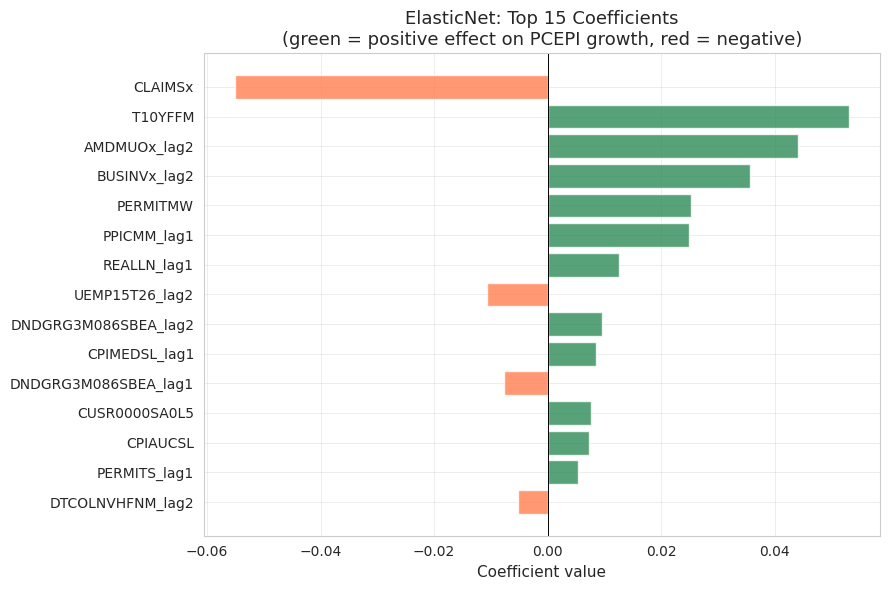

In [10]:
importance_df = elasticnet.get_feature_importance(feature_names)

if importance_df is not None:
    top15 = importance_df.head(15)
    print("Top 15 features by |ElasticNet coefficient|:")
    print(top15.to_string(index=False))

    # Also show signed coefficients for direction
    coef_df = pd.DataFrame({
        'feature': feature_names,
        'coefficient': elasticnet.model.coef_
    }).sort_values('coefficient', key=abs, ascending=False)

    non_zero = (coef_df['coefficient'] != 0).sum()
    print(f"\nNon-zero coefficients: {non_zero} / {len(feature_names)}")
    print("(ElasticNet sparsity: L1 penalty drives many to exactly zero)")

    fig, ax = plt.subplots(figsize=(9, 6))
    colors = ['steelblue' if c >= 0 else 'coral' for c in top15['importance'].values]
    # Use signed coef for the top-15 selected by |coef|
    signed_top15 = coef_df.head(15)
    bar_colors = ['seagreen' if c >= 0 else 'coral' for c in signed_top15['coefficient']]
    ax.barh(signed_top15['feature'], signed_top15['coefficient'], color=bar_colors, alpha=0.8)
    ax.axvline(0, color='black', linewidth=0.7)
    ax.set_xlabel('Coefficient value')
    ax.set_title('ElasticNet: Top 15 Coefficients\n(green = positive effect on PCEPI growth, red = negative)')
    ax.invert_yaxis()
    fig.tight_layout()
    plt.show()